In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("311_Service_Requests_from_2010_to_Present.csv",low_memory=False)

In [3]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [4]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [5]:
df.shape

(364558, 53)

In [6]:
df.isnull().sum()

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

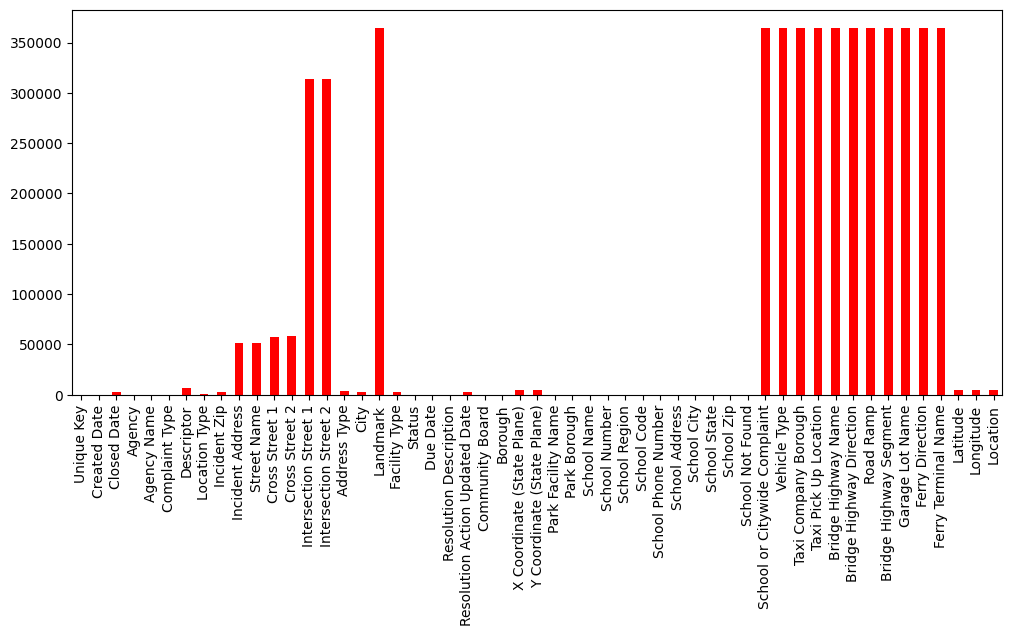

In [7]:
plt.figure(figsize=(12,5))
df.isnull().sum().plot(kind='bar',color='r')
plt.show()

In [8]:
df = df[df['Closed Date'].notnull()]

In [9]:
df['Closed Date']

0         01/01/2016 12:55:15 AM
1         01/01/2016 01:26:57 AM
2         01/01/2016 04:51:03 AM
3         01/01/2016 07:43:13 AM
4         01/01/2016 03:24:42 AM
                   ...          
364553    01/01/2015 10:22:31 AM
364554    01/01/2015 02:25:02 AM
364555    01/01/2015 12:20:33 AM
364556    01/01/2015 02:42:22 AM
364557    01/01/2015 02:47:50 AM
Name: Closed Date, Length: 362177, dtype: object

In [10]:
df.isnull().sum()

Unique Key                             0
Created Date                           0
Closed Date                            0
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6496
Location Type                        130
Incident Zip                         675
Incident Address                   51686
Street Name                        51686
Cross Street 1                     55331
Cross Street 2                     55464
Intersection Street 1             311549
Intersection Street 2             311673
Address Type                         929
City                                 674
Landmark                          361802
Facility Type                         18
Status                                 0
Due Date                               1
Resolution Description                 0
Resolution Action Updated Date        39
Community Board                        0
Borough         

In [11]:
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Closed Date'] = pd.to_datetime(df['Closed Date'])

C:\Users\admin\AppData\Local\Temp\ipykernel_15648\1322958625.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Created Date'] = pd.to_datetime(df['Created Date'])
C:\Users\admin\AppData\Local\Temp\ipykernel_15648\1322958625.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Closed Date'] = pd.to_datetime(df['Closed Date'])


In [12]:
df['Created Date']

0        2015-12-31 23:59:45
1        2015-12-31 23:59:44
2        2015-12-31 23:59:29
3        2015-12-31 23:57:46
4        2015-12-31 23:56:58
                 ...        
364553   2015-01-01 00:04:44
364554   2015-01-01 00:04:28
364555   2015-01-01 00:01:30
364556   2015-01-01 00:01:29
364557   2015-01-01 00:00:50
Name: Created Date, Length: 362177, dtype: datetime64[ns]

In [13]:
df['Request_Closing_Time'] = df['Closed Date'] - df['Created Date']

In [14]:
df['Request_Closing_Time'].head(25)

0    0 days 00:55:30
1    0 days 01:27:13
2    0 days 04:51:34
3    0 days 07:45:27
4    0 days 03:27:44
5    0 days 01:53:41
6    0 days 01:58:22
7    0 days 01:48:49
8    0 days 08:33:34
9    0 days 01:23:42
10   0 days 07:48:40
11   0 days 11:07:11
12   0 days 02:29:56
13   0 days 08:30:49
14   0 days 10:29:45
15   0 days 15:33:27
16   0 days 04:52:39
17   0 days 00:51:18
18   0 days 02:56:29
19   0 days 00:47:36
20   0 days 04:31:52
21   0 days 09:32:42
22   0 days 01:16:38
23   0 days 00:52:35
24   2 days 16:51:12
Name: Request_Closing_Time, dtype: timedelta64[ns]

In [15]:
df['Request_Closing_Time'] = df['Request_Closing_Time'].dt.total_seconds()

In [16]:
df['Request_Closing_Time'].head(25)

0       3330.0
1       5233.0
2      17494.0
3      27927.0
4      12464.0
5       6821.0
6       7102.0
7       6529.0
8      30814.0
9       5022.0
10     28120.0
11     40031.0
12      8996.0
13     30649.0
14     37785.0
15     56007.0
16     17559.0
17      3078.0
18     10589.0
19      2856.0
20     16312.0
21     34362.0
22      4598.0
23      3155.0
24    233472.0
Name: Request_Closing_Time, dtype: float64

In [17]:
df = df[df['Request_Closing_Time'] >= 0]
df['Request_Closing_Time']

0          3330.0
1          5233.0
2         17494.0
3         27927.0
4         12464.0
           ...   
364553    37067.0
364554     8434.0
364555     1143.0
364556     9653.0
364557    10020.0
Name: Request_Closing_Time, Length: 362177, dtype: float64

In [18]:
df['Complaint Type'].isnull().sum()

np.int64(0)

In [19]:
df['City'] = df['City'].fillna("Unknown")

In [20]:
df['City'].head(50)

0                NEW YORK
1                 ASTORIA
2                   BRONX
3                   BRONX
4                ELMHURST
5                BROOKLYN
6                NEW YORK
7                   BRONX
8             KEW GARDENS
9                BROOKLYN
10        JACKSON HEIGHTS
11                  BRONX
12                  BRONX
13               BROOKLYN
14         MIDDLE VILLAGE
15              REGO PARK
16           SAINT ALBANS
17               BROOKLYN
18               BROOKLYN
19               NEW YORK
20                  BRONX
21         MIDDLE VILLAGE
22               BROOKLYN
23               NEW YORK
24                  BRONX
25                JAMAICA
26               NEW YORK
27    SOUTH RICHMOND HILL
28               NEW YORK
29               BROOKLYN
30               BROOKLYN
31               BROOKLYN
32                  BRONX
33                Unknown
34              RIDGEWOOD
35           HOWARD BEACH
36               BROOKLYN
37           FOREST HILLS
38          

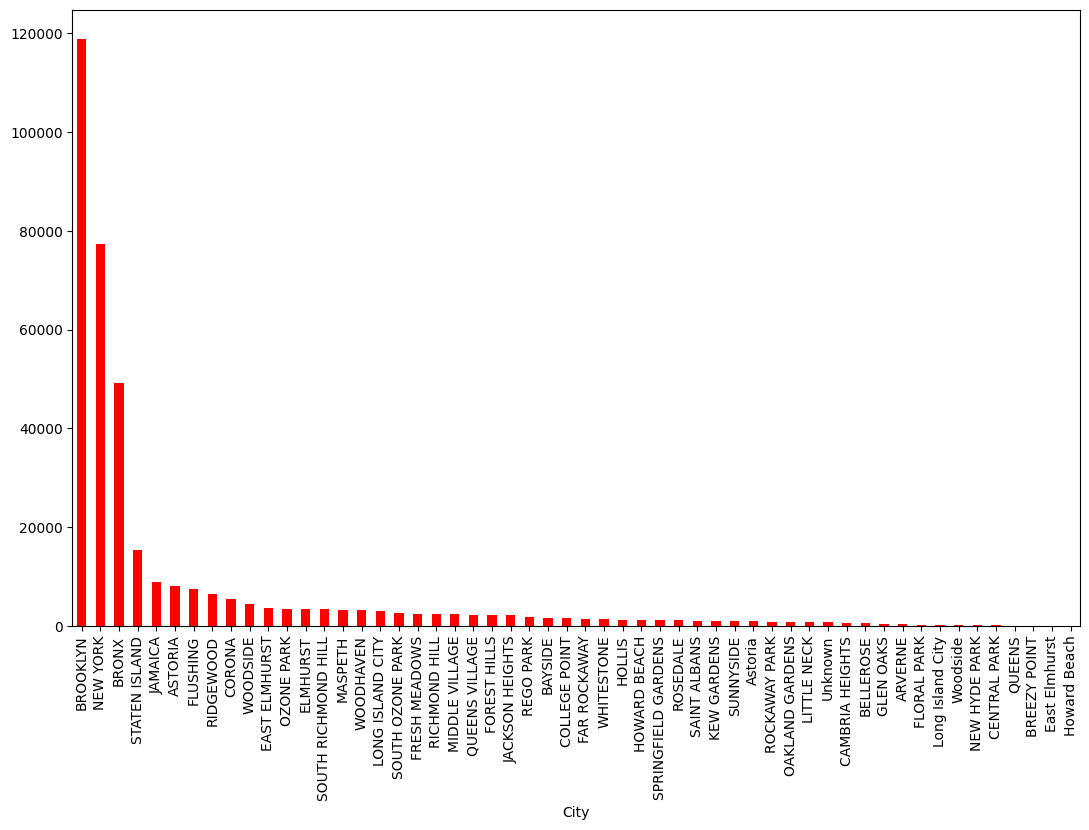

In [21]:
plt.figure(figsize=(13,8))
df['City'].value_counts().plot(kind='bar',color='red')
plt.show()

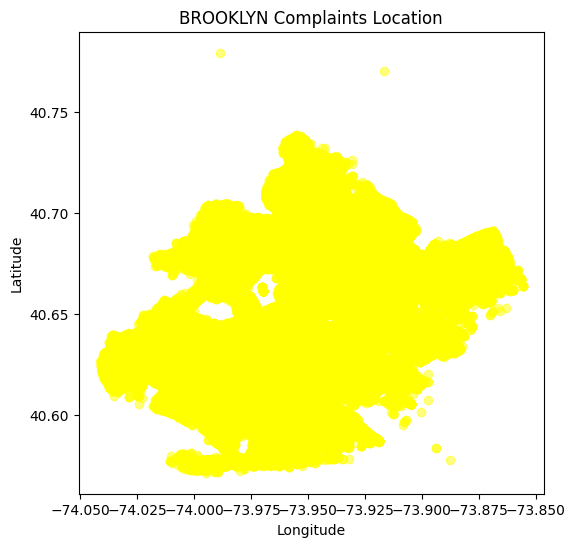

In [22]:
BROOKLYN = df[df['City'] == 'BROOKLYN']
plt.figure(figsize=(6,6))
plt.scatter(BROOKLYN['Longitude'], BROOKLYN['Latitude'], alpha=0.5,color='yellow')
plt.title("BROOKLYN Complaints Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

<Figure size 1300x800 with 0 Axes>

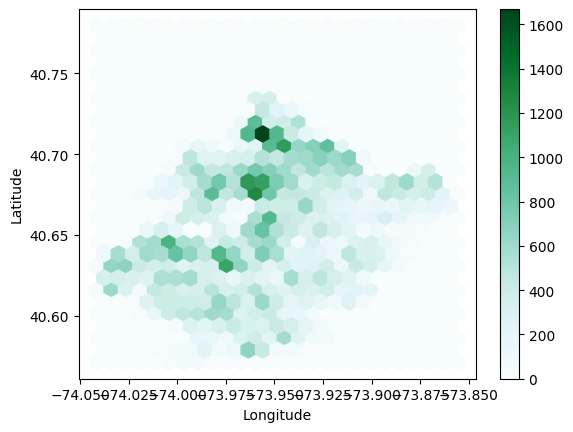

In [23]:
plt.figure(figsize=(13,8))
BROOKLYN.plot.hexbin(x='Longitude', y='Latitude', gridsize=25)
plt.show()

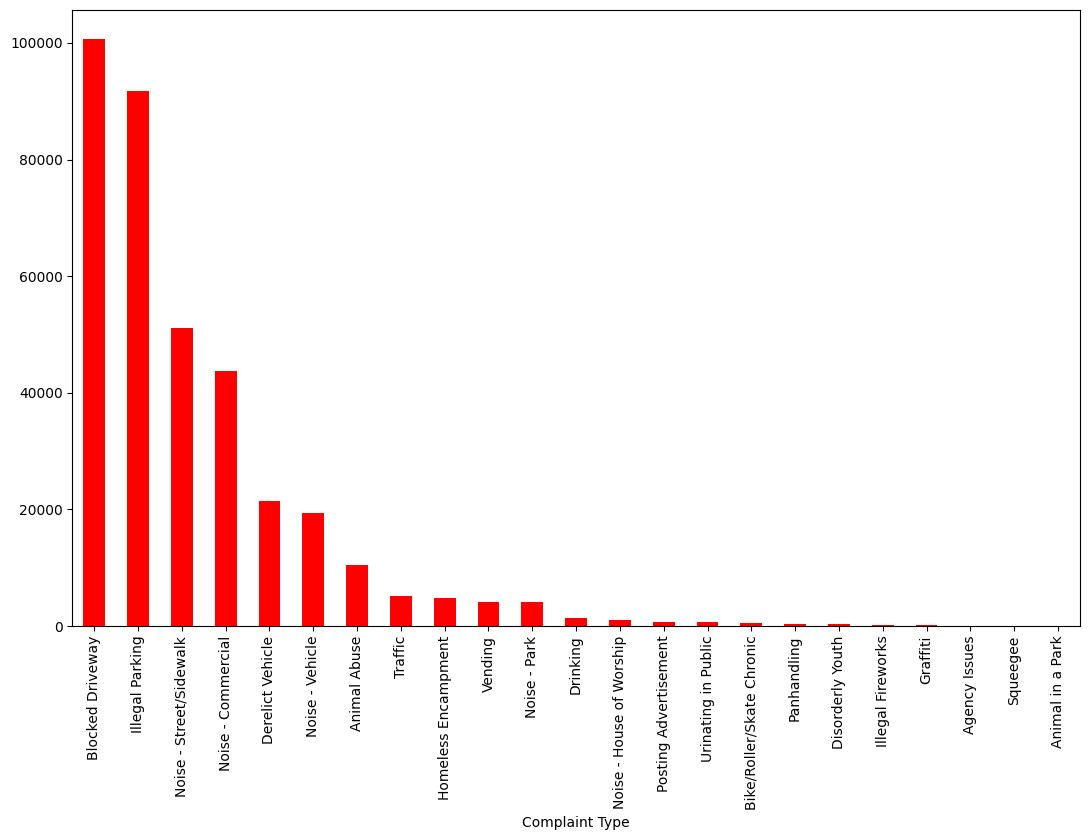

In [24]:
plt.figure(figsize=(13,8))
df['Complaint Type'].value_counts().plot(kind='bar',color='red')
plt.show()

In [25]:
pratham = df[df['City'] == 'NEW YORK']
pratham['Complaint Type'].value_counts()

Complaint Type
Noise - Street/Sidewalk      22245
Noise - Commercial           18686
Illegal Parking              14549
Noise - Vehicle               6294
Homeless Encampment           3060
Blocked Driveway              2705
Vending                       2638
Animal Abuse                  1941
Traffic                       1769
Noise - Park                  1243
Derelict Vehicle               695
Drinking                       321
Urinating in Public            264
Bike/Roller/Skate Chronic      254
Noise - House of Worship       222
Panhandling                    206
Disorderly Youth                81
Posting Advertisement           49
Illegal Fireworks               38
Graffiti                        25
Squeegee                         4
Name: count, dtype: int64

In [26]:
df['Complaint Type'].value_counts().head(10)

Complaint Type
Blocked Driveway           100624
Illegal Parking             91716
Noise - Street/Sidewalk     51139
Noise - Commercial          43751
Derelict Vehicle            21518
Noise - Vehicle             19301
Animal Abuse                10530
Traffic                      5196
Homeless Encampment          4879
Vending                      4185
Name: count, dtype: int64

In [27]:
df.groupby(['City','Complaint Type']).size()

City      Complaint Type         
ARVERNE   Animal Abuse                46
          Blocked Driveway            50
          Derelict Vehicle            32
          Disorderly Youth             2
          Drinking                     1
                                    ... 
Woodside  Blocked Driveway            27
          Derelict Vehicle             8
          Illegal Parking            124
          Noise - Commercial           2
          Noise - Street/Sidewalk      5
Length: 792, dtype: int64

In [28]:
df_new = pd.crosstab(df['Complaint Type'], df['City'])

In [29]:
df_new.head()

City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,...,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,Unknown,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,
Agency Issues,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,8,0,0,0,0
Animal Abuse,46,170,0,53,15,2,1971,3191,15,0,...,74,40,42,786,40,1,43,57,111,0
Animal in a Park,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bike/Roller/Skate Chronic,0,16,0,0,1,0,22,124,0,0,...,1,1,0,10,2,2,4,2,5,0
Blocked Driveway,50,3436,159,514,138,3,17062,36445,177,0,...,1202,1946,330,2845,278,86,279,1363,2038,27


<Figure size 1200x600 with 0 Axes>

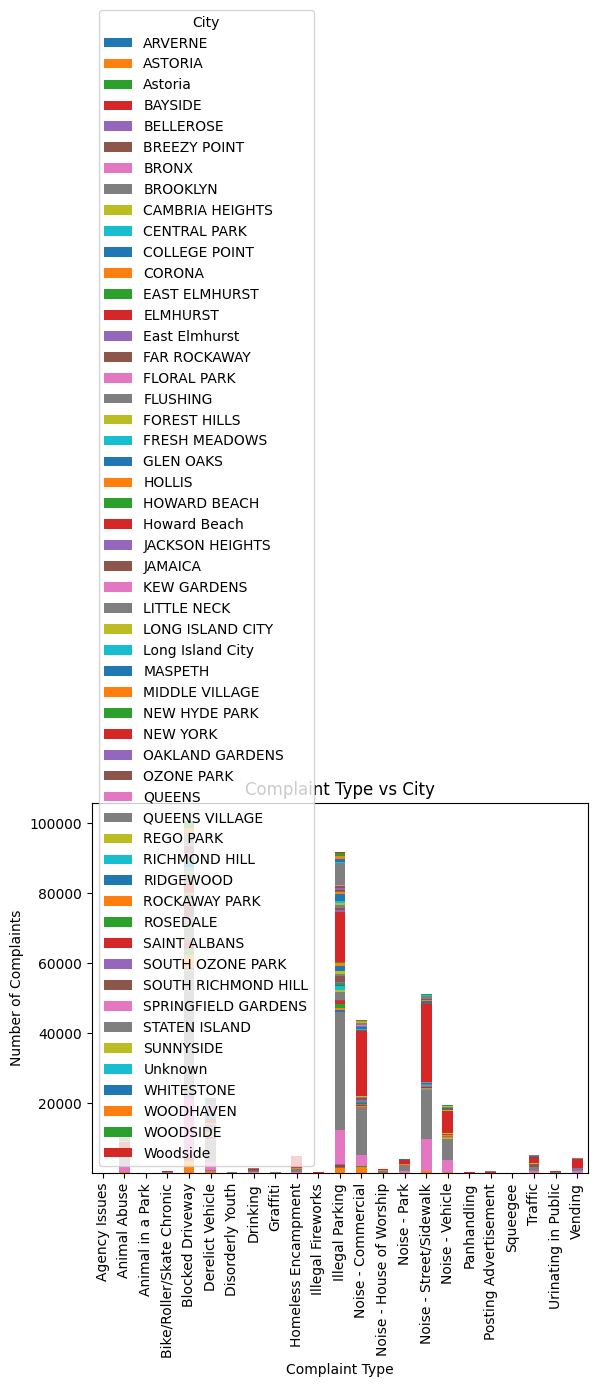

In [30]:
plt.figure(figsize=(12,6))
df_new.plot(kind='bar', stacked=True)
plt.title("Complaint Type vs City")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.legend(title="City")
plt.show()

In [31]:
df.groupby('Complaint Type')['Request_Closing_Time'].mean().sort_values()

Complaint Type
Posting Advertisement        7.286256e+03
Illegal Fireworks            1.011348e+04
Noise - Commercial           1.108576e+04
Noise - House of Worship     1.139109e+04
Noise - Park                 1.222606e+04
Noise - Street/Sidewalk      1.223130e+04
Traffic                      1.230912e+04
Disorderly Youth             1.236375e+04
Noise - Vehicle              1.256180e+04
Urinating in Public          1.295929e+04
Bike/Roller/Skate Chronic    1.312369e+04
Drinking                     1.382130e+04
Vending                      1.436628e+04
Squeegee                     1.456025e+04
Homeless Encampment          1.545138e+04
Illegal Parking              1.565044e+04
Panhandling                  1.585355e+04
Blocked Driveway             1.623252e+04
Animal Abuse                 1.803256e+04
Agency Issues                1.828912e+04
Graffiti                     2.327634e+04
Derelict Vehicle             2.535960e+04
Animal in a Park             1.212634e+06
Name: Request_Closi

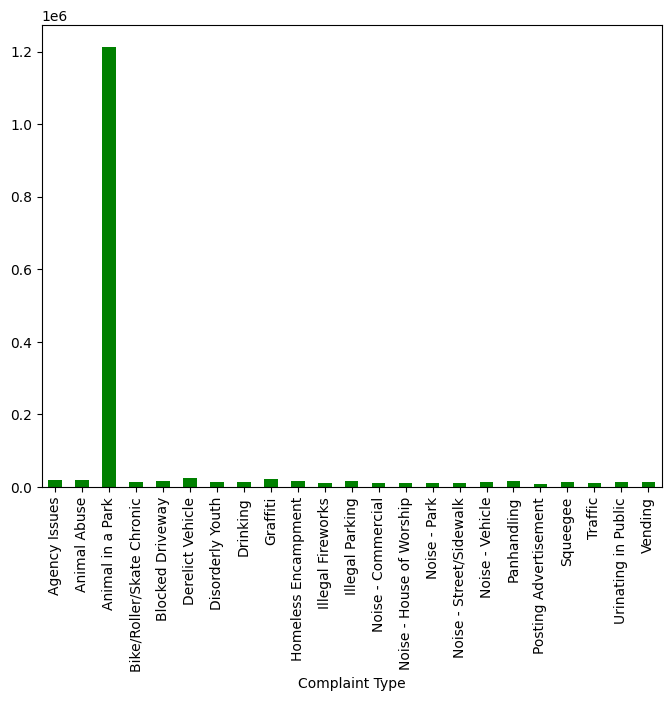

In [32]:
plt.figure(figsize=(8,6))
df.groupby('Complaint Type')['Request_Closing_Time'].mean().plot(kind='bar',color ='green')
plt.show()

In [33]:
from scipy.stats import kruskal
types = df['Complaint Type'].unique()
groups = [df[df['Complaint Type']==t]['Request_Closing_Time'] for t in types[:5]]
kruskal(*groups)

KruskalResult(statistic=np.float64(10028.143068069874), pvalue=np.float64(0.0))